In [70]:
from astropy.table import Table
from glob import glob
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
from matplotlib import colors
import matplotlib.ticker as ticker
import numpy as np
import os
import pathlib
import pandas as pd
import polars as pl

In [71]:
os.chdir(pathlib.Path.cwd())
def set_rcparams():
    tab = Table.read('rcparams.txt', format='csv')
    for i in range(len(tab)):
        try:
            plt.rcParams[tab['key'][i]] = float(tab['val'][i])
        except ValueError:
            plt.rcParams[tab['key'][i]] = str(tab['val'][i])
    return
set_rcparams()

In [ ]:
gaiaids = pl.read_parquet('(#path to#)/allgaiadata.parq').to_pandas()
gidssmol = gaiaids[['asas_sn_id', 'gaia_id']]
del gaiaids

In [ ]:
allpred = pd.read_csv('(#path to#)/0fullpred.csv', header=None, names=['asas_sn_id', 'period', 'sigma'])

In [ ]:
predcitionsandgaia = pd.merge(gidssmol, allpred, on='asas_sn_id', how='inner').drop_duplicates(subset=['asas_sn_id'])

In [ ]:
idmatch = Table.read('files/kepler_dr2_1arcsec.fits', format='fits').to_pandas()
idmatch = idmatch.drop_duplicates(subset=['kepid'])
idmatcher = idmatch[['kepid', 'source_id']]
idmatcher = idmatcher.rename(columns={'kepid':'KIC', 'source_id':'gaia_id'})

In [ ]:
gaiatotic = pd.merge(idmatcher, predcitionsandgaia, on='gaia_id', how='inner')
del predcitionsandgaia, idmatcher, idmatch, allpred

In [ ]:
santos1 = Table.read('files/crossmatch/santos1.txt', format="ascii.cds").to_pandas()
santos2 = Table.read('files/crossmatch/santos2.txt', format="ascii.cds").to_pandas()
santostot = pd.concat([santos1, santos2])

In [121]:
santosmatch = pd.merge(santostot, gaiatotic, on='KIC', how='inner')
santosmatch['frac_err'] =  santosmatch['sigma']/santosmatch['period']
santosmatch['diff'] = np.abs((santosmatch['period']-santosmatch['Prot'])) / santosmatch['Prot']


In [122]:
# Sigma for Santos crossmatched

numtwosig = len(santosmatch[santosmatch['sigma']<=2])
numthreesig = len(santosmatch[santosmatch['sigma']<=3])
numfivesig = len(santosmatch[santosmatch['sigma']<=5])
num7sig = len(santosmatch[santosmatch['sigma']<=7])

tot = len(santosmatch) 

twosigpercen = numtwosig/tot * 100
threesigpercen =  numthreesig/tot * 100
fivesigpercen =  numfivesig/tot * 100
sevperc = num7sig/tot * 100

sig2 = santosmatch[santosmatch['sigma']<=2]
goodsig2 = sig2[sig2['diff']<=0.1]
percsig2 = (len(goodsig2)/len(sig2)) * 100

sig3 = santosmatch[santosmatch['sigma']<=3]
goodsig3 = sig3[sig3['diff']<=0.1]
percsig3 = (len(goodsig3)/len(sig3)) * 100

sig5 = santosmatch[santosmatch['sigma']<=5]
goodsig5 = sig5[sig5['diff']<=0.1]
percsig5 = (len(goodsig5)/len(sig5)) * 100

sig7 = santosmatch[santosmatch['sigma']<=7]
goodsig7 = sig7[sig7['diff']<=0.1]
percsig7 = (len(goodsig7)/len(sig7)) * 100

# Fractional Error for Santos crossmatched

fracerrnum50 = len(santosmatch[santosmatch['frac_err']<=0.5])
fracerrnum25 = len(santosmatch[santosmatch['frac_err']<=0.25])
fracerrnum10 = len(santosmatch[santosmatch['frac_err']<=0.1])

tot = len(santosmatch) 

fracerrnum50perc = fracerrnum50/tot * 100
fracerrnum25perc = fracerrnum25/tot * 100
fracerrnum10perc =  fracerrnum10/tot * 100

frac50 = santosmatch[santosmatch['frac_err']<=0.5]
goodfrac50 = frac50[frac50['diff']<=0.1]
percfrac50 = (len(goodfrac50)/len(frac50)) * 100

frac25 = santosmatch[santosmatch['frac_err']<=0.25]
goodfrac25 = frac25[frac25['diff']<=0.1]
percfrac25 = (len(goodfrac25)/len(frac25)) * 100

frac10 = santosmatch[santosmatch['frac_err']<=0.1]
goodfrac10 = frac10[frac10['diff']<=0.1]
percfrac10 = (len(goodfrac10)/len(frac10)) * 100

Total of 41825 periods matched to Santos et al.


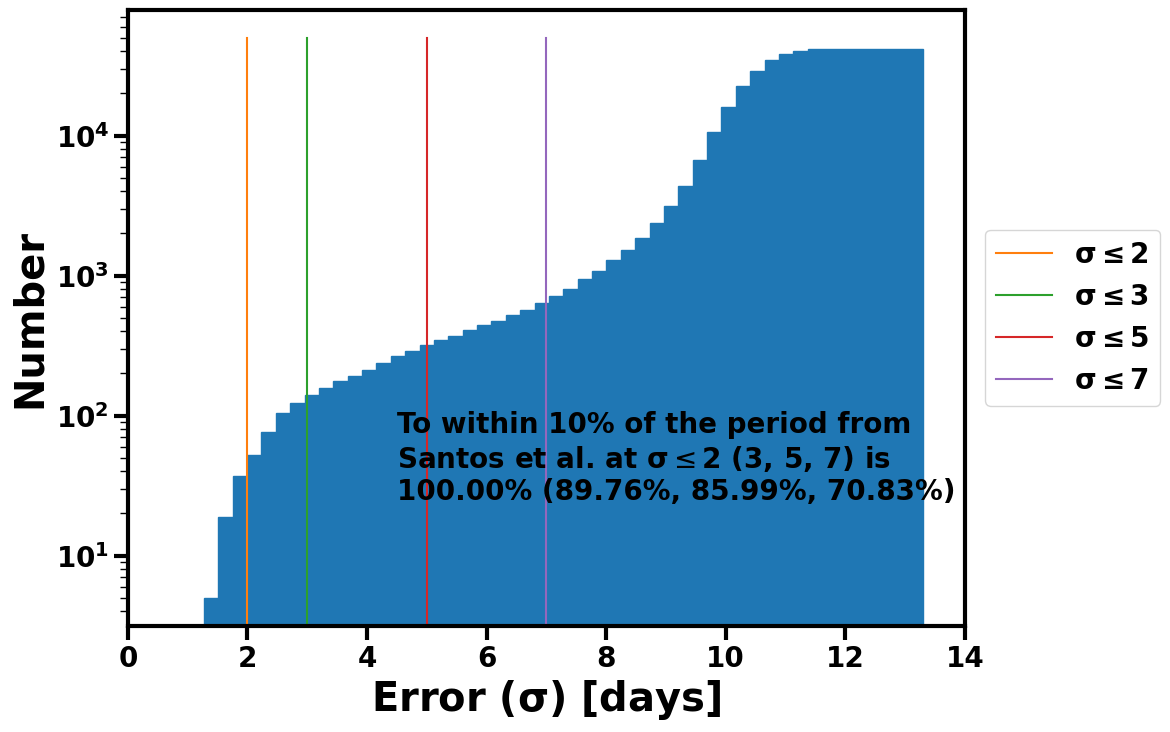

In [128]:
fig, ax = plt.subplots(figsize=(12, 8), layout='constrained')
print(f'Total of {len(santosmatch)} periods matched to Santos et al.')
formatter1 = ticker.FormatStrFormatter('%.0')
ax.xaxis.set_major_formatter(formatter1)

ax.hist(santosmatch['sigma'], bins=50, cumulative=True, fill=True, histtype='step')
ax.plot([2, 2], [0, 50000], label='$\\bf{\sigma} \leq 2$')
ax.plot([3, 3], [0, 50000], label='$\\bf{\sigma} \leq 3$')
ax.plot([5, 5], [0, 50000], label='$\\bf{\sigma} \leq 5$')
ax.plot([7, 7], [0, 50000], label='$\\bf{\sigma} \leq 7$')
ax.text(4.5, 25, f'To within 10% of the period from \nSantos et al. at $\\bf\sigma$$\leq$2 (3, 5, 7) is \n{"%.2f" % percsig2}% ({"%.2f" % percsig3}%, {"%.2f" % percsig5}%, {"%.2f" % percsig7}%)', fontweight='bold', rasterized=True)
ax.set_xlabel(r'Error ($\mathbf{\sigma}$) [days]')
ax.set_ylabel('Number')

yticksl = ax.get_yticks()
ax.set_yticks(ticks = yticksl, labels=yticksl, weight='bold')
ax.set_xticks(ticks = [0, 2, 4, 6, 8, 10, 12, 14], labels=[0, 2, 4, 6, 8, 10, 12, 14], weight='bold')

ax.set_yscale('log')
pos = ax.get_position()
ax.set_position([pos.x0, pos.y0, pos.width * 0.9, pos.height])
legend = ax.legend(loc='center right', bbox_to_anchor=(1.25, 0.5))

Total of 41825 periods matched to Santos et al.


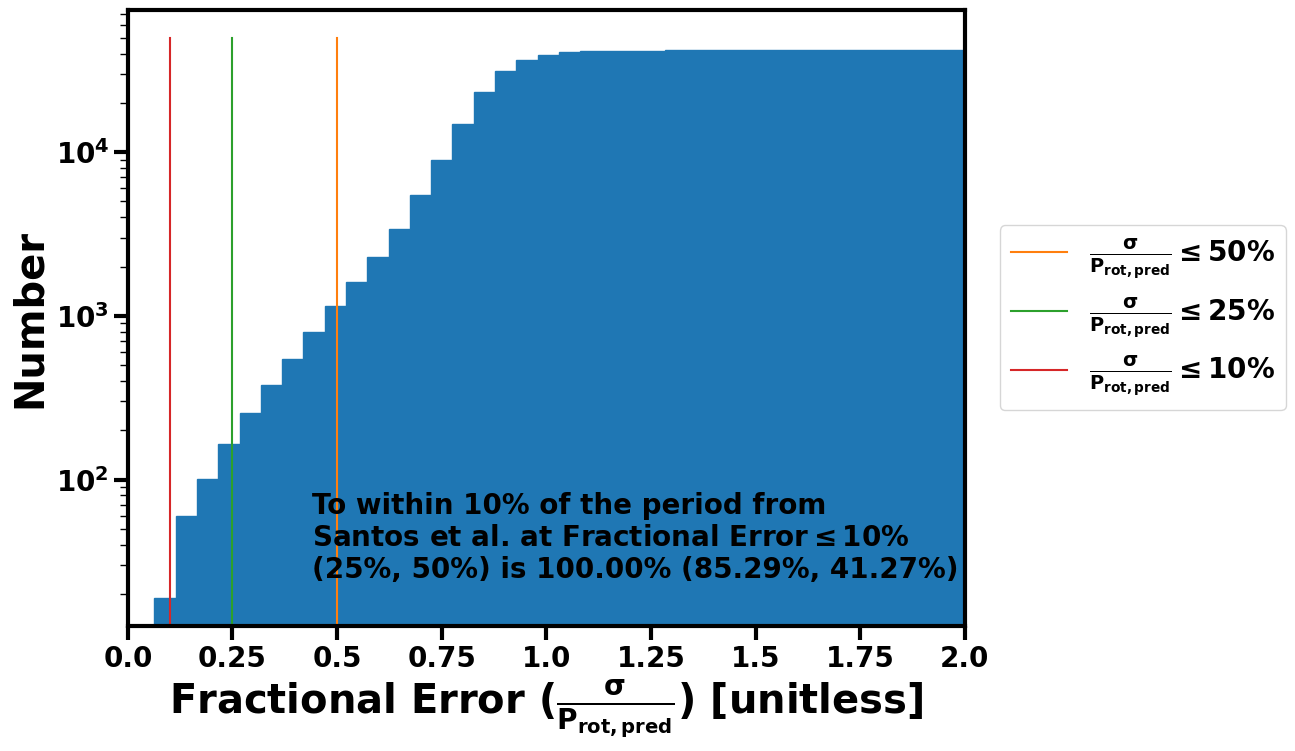

In [131]:
fig, ax = plt.subplots(figsize=(12, 8), layout='constrained')
ax.set_xlim(0, 2)
title = r"Fractional Error"
print(f'Total of {len(santosmatch)} periods matched to Santos et al.')
formatter1 = ticker.FormatStrFormatter('%.2f')
ax.xaxis.set_major_formatter(formatter1)

ax.hist(santosmatch['frac_err'], bins=50, cumulative=True, fill=True, histtype='step')
ax.plot([0.5, 0.5], [0, 50000], label=r'$\mathbf{\frac{\sigma}{P_{rot, pred}} \leq 50\%}$')
ax.plot([0.25, 0.25], [0, 50000], label=r'$\mathbf{\frac{\sigma}{P_{rot, pred}}  \leq 25\%}$')
ax.plot([0.1, 0.1], [0, 50000], label=r'$\mathbf{\frac{\sigma}{P_{rot, pred}}  \leq 10\%}$')
ax.text(0.44, 25, f'To within 10% of the period from \nSantos et al. at {title}$\\bf\leq$10% \n(25%, 50%) is {"%.2f" % percfrac10}% ({"%.2f" % percfrac25}%, {"%.2f" % percfrac50}%)', fontweight='bold', rasterized=True)

ax.set_xlabel(r'Fractional Error ($\mathbf{\frac{\sigma}{P_{rot, pred}}}$) [unitless]')
ax.set_ylabel('Number')

xticksl = ax.get_xticks()
yticksl = ax.get_yticks()
ax.set_yticks(ticks = yticksl, labels=yticksl, weight='bold')
ax.set_xticks(ticks = xticksl, labels=xticksl, weight='bold')

ax.set_yscale('log')
pos = ax.get_position()
ax.set_position([pos.x0, pos.y0, pos.width * 0.9, pos.height])
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))


In [132]:
sim_input_log6 = "files/testing_csvs_section5/simulation_input_30_log6.csv"
cnn_periodsl6 = pd.read_csv(sim_input_log6, header=0, index_col="simulation_number").sort_index().rename(columns={'period':'true_period'})
cnn_periodsl6.index.names = ['sim_id']
cnn_periods_test_log6 = cnn_periodsl6[900000:]
table3_row1 = pd.read_csv("files/testing_csvs_section5/6_clump_nor_norm_nan_all/asassn_clump_0_predictions.csv", header=0).sort_index().join(cnn_periodsl6, how="inner").eval("frac = sigma/period").query("period > 0")
table3_row1['frac_err'] = table3_row1['sigma']/table3_row1['period']
table3_row1['diff'] = np.abs(table3_row1['period']- table3_row1['true_period'])/table3_row1['true_period']

In [133]:
#Sigma stuff for test set

numtwosig = len(table3_row1[table3_row1['sigma']<=2])
numthreesig = len(table3_row1[table3_row1['sigma']<=3])
numfivesig = len(table3_row1[table3_row1['sigma']<=5])
num7sig = len(table3_row1[table3_row1['sigma']<=7])

tot = len(table3_row1) 

twosigpercen = numtwosig/tot * 100
threesigpercen =  numthreesig/tot * 100
fivesigpercen =  numfivesig/tot * 100

sevperc = num7sig/tot * 100

sig2 = table3_row1[table3_row1['sigma']<=2]
goodsig2 = sig2[sig2['diff']<=0.1]
percsig2 = (len(goodsig2)/len(sig2)) * 100

sig3 = table3_row1[table3_row1['sigma']<=3]
goodsig3 = sig3[sig3['diff']<=0.1]
percsig3 = (len(goodsig3)/len(sig3)) * 100

sig5 = table3_row1[table3_row1['sigma']<=5]
goodsig5 = sig5[sig5['diff']<=0.1]
percsig5 = (len(goodsig5)/len(sig5)) * 100

sig7 = table3_row1[table3_row1['sigma']<=7]
goodsig7 = sig7[sig7['diff']<=0.1]
percsig7 = (len(goodsig7)/len(sig7)) * 100

#Fractional Error stuff for test set

fracerrnum50 = len(table3_row1[table3_row1['frac_err']<=0.5])
fracerrnum25 = len(table3_row1[table3_row1['frac_err']<=0.25])
fracerrnum10 = len(table3_row1[table3_row1['frac_err']<=0.1])

tot = len(table3_row1) 

fracerrnum50perc = fracerrnum50/tot * 100
fracerrnum25perc = fracerrnum25/tot * 100
fracerrnum10perc =  fracerrnum10/tot * 100

frac50 = table3_row1[table3_row1['frac_err']<=0.5]
goodfrac50 = frac50[frac50['diff']<=0.1]
percfrac50 = (len(goodfrac50)/len(frac50)) * 100

frac25 = table3_row1[table3_row1['frac_err']<=0.25]
goodfrac25 = frac25[frac25['diff']<=0.1]
percfrac25 = (len(goodfrac25)/len(frac25)) * 100

frac10 = table3_row1[table3_row1['frac_err']<=0.1]
goodfrac10 = frac10[frac10['diff']<=0.1]
percfrac10 = (len(goodfrac10)/len(frac10)) * 100

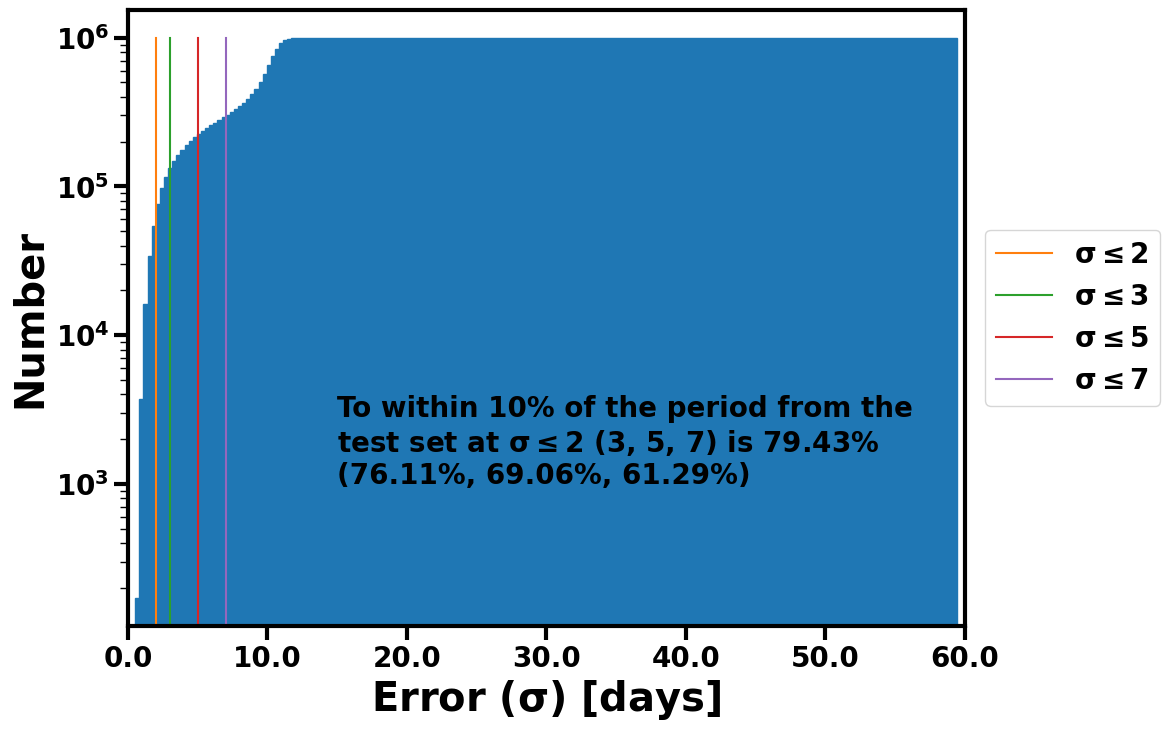

In [136]:
fig, ax = plt.subplots(figsize=(12, 8), layout='constrained')
ax.set_xlim(0, 60)
formatter1 = ticker.FormatStrFormatter('%.0f')
ax.xaxis.set_major_formatter(formatter1)

ax.hist(table3_row1['sigma'], bins=200, cumulative=True, fill=True, histtype='step', rasterized=True)
ax.plot([2, 2], [0, 1000000], label='$\\bf{\sigma} \leq 2$')
ax.plot([3, 3], [0, 1000000], label='$\\bf{\sigma} \leq 3$')
ax.plot([5, 5], [0, 1000000], label='$\\bf{\sigma} \leq 5$')
ax.plot([7, 7], [0, 1000000], label='$\\bf{\sigma} \leq 7$')
ax.text(15, 1000, f'To within 10% of the period from the \ntest set at $\\bf\sigma\leq$2 (3, 5, 7) is {"%.2f" % percsig2}% \n({"%.2f" % percsig3}%, {"%.2f" % percsig5}%, {"%.2f" % percsig7}%)', fontweight='bold', rasterized=True)
ax.set_xlabel(r'Error ($\mathbf{\sigma}$) [days]')
ax.set_ylabel('Number')

xticksl = ax.get_xticks()
yticksl = ax.get_yticks()
ax.set_yticks(ticks = yticksl, labels=yticksl, weight='bold')
ax.set_xticks(ticks = xticksl, labels=xticksl, weight='bold')

ax.set_yscale('log')
pos = ax.get_position()
ax.set_position([pos.x0, pos.y0, pos.width * 0.9, pos.height])
legend = ax.legend(loc='center right', bbox_to_anchor=(1.25, 0.5))

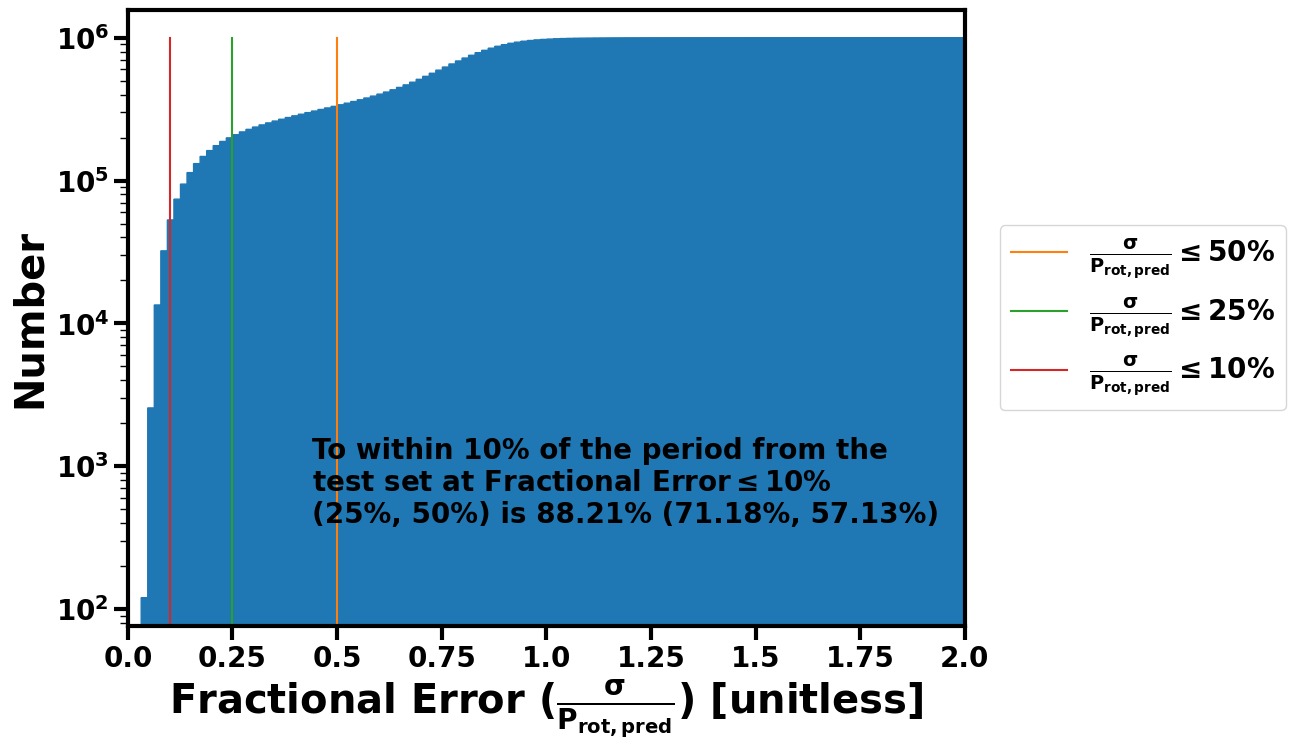

In [139]:
fig, ax = plt.subplots(figsize=(12, 8), layout='constrained')
ax.set_xlim(0, 2)
title = "Fractional Error"
formatter1 = ticker.FormatStrFormatter('%.2f')
ax.xaxis.set_major_formatter(formatter1)
ax.xaxis.set_major_formatter(formatter1)


ax.hist(table3_row1['frac_err'], bins=2000, cumulative=True, fill=True, histtype='step', rasterized=True)
ax.plot([0.5, 0.5], [0, 1000000], label=r'$\mathbf{\frac{\sigma}{P_{rot, pred}} \leq 50\%}$')
ax.plot([0.25, 0.25], [0, 1000000], label=r'$\mathbf{\frac{\sigma}{P_{rot, pred}}  \leq 25\%}$')
ax.plot([0.1, 0.1], [0, 1000000], label=r'$\mathbf{\frac{\sigma}{P_{rot, pred}}  \leq 10\%}$')
ax.text(0.44, 400, f'To within 10% of the period from the \ntest set at {title}$\\bf\leq$10% \n(25%, 50%) is {"%.2f" % percfrac10}% ({"%.2f" % percfrac25}%, {"%.2f" % percfrac50}%)', fontweight='bold', rasterized=True)
ax.set_xlabel(r'Fractional Error ($\mathbf{\frac{\sigma}{P_{rot, pred}}}$) [unitless]')
ax.set_ylabel('Number')

xticksl = ax.get_xticks()
yticksl = ax.get_yticks()
ax.set_yticks(ticks = yticksl, labels=yticksl, weight='bold')
ax.set_xticks(ticks = xticksl, labels=xticksl, weight='bold')

ax.set_yscale('log')
pos = ax.get_position()
ax.set_position([pos.x0, pos.y0, pos.width * 0.9, pos.height])
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))

In [266]:
uncertainties = [1.3, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5, 5.5, 6, 6.5, 7, 7.5, 8, 8.5, 9, 9.5, 10, 10.5, 11, 11.5, 12, 12.5, 13, 13.5, 14, 14.5, 15, 15.5, 16, 16.5, 17]
numdetected = []
fracdetected = []
percenttoten = []

for uncertainty in uncertainties:
    detected = santosmatch[santosmatch['sigma'] <= uncertainty]
    fracdetect = len(detected) / len(santosmatch)
    good = detected[detected['diff']<=0.1]
    try:
        percentrightten = (len(good)/len(detected)) * 100
    except:
        percentrightten = 0
    numdetected.append(len(detected))
    fracdetected.append(fracdetect)
    percenttoten.append(percentrightten)

In [267]:
def NormalizeData(data):
    return (data - np.min(data)) / (np.max(data) - np.min(data)) * 100

In [268]:
fracdetectedfin = NormalizeData(fracdetected)

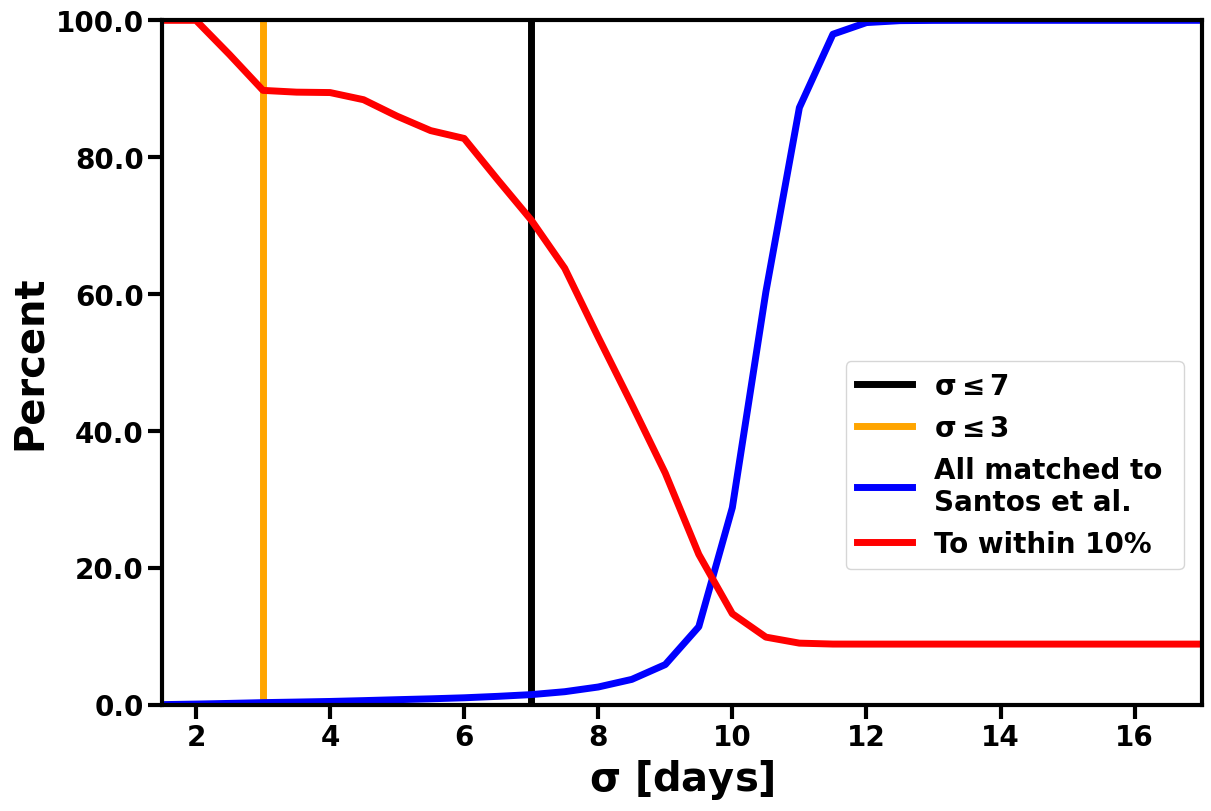

In [269]:
fig, ax = plt.subplots(figsize=(12, 8), layout='constrained')
ax.set(ylim=(0, 100), xlim=(1.5, 17))

formatter = ticker.FormatStrFormatter('%.0')
ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)

ax.plot([7, 7], [0, 100], c='k', label='$\\bf\sigma\leq$7', linewidth=5)
ax.plot([3, 3], [0, 100], c='orange',label='$\\bf\sigma\leq$3', linewidth=5)

ax.plot(uncertainties, fracdetectedfin, c='b', label='All matched to \nSantos et al.', linewidth=5)
ax.plot(uncertainties, percenttoten, c='r', label='To within 10%', linewidth=5)

yticksl = ax.get_yticks()
ax.set_yticks(ticks = yticksl, labels=yticksl, weight='bold')
ax.set_xticks(ticks = [2, 4, 6, 8, 10, 12, 14, 16], labels=[2, 4, 6, 8, 10, 12, 14, 16], weight='bold')

ax.set_xlabel(r'$\mathbf{\sigma}$ [days]')
ax.set_ylabel('Percent')
ax.legend(prop={'weight': 'bold'}, bbox_to_anchor=(0.82, 0.35), loc='center')
plt.savefig('sigma_uplot.pdf', dpi=300)

In [270]:
uncertainties = [0.075, 0.1, 0.15, 0.2, 0.25, 0.35, 0.4, 0.45, 0.5,
                 0.55, 0.6, 0.65, 0.7, 0.75, 0.85, 0.9, 0.95, 1,
                 1.05, 1.1, 1.15, 1.2, 1.25, 1.35, 1.4, 1.45, 1.5]
numdetected = []
fracdetected = []
percenttoten = []
for uncertainty in uncertainties:
    detected = santosmatch[santosmatch['frac_err'] <= uncertainty]
    fracdetect = len(detected) / len(santosmatch)
    good = detected[detected['diff']<=0.1]
    try:
        percentrightten = (len(good)/len(detected)) * 100
    except:
        percentrightten = 0
    numdetected.append(len(detected))
    fracdetected.append(fracdetect)
    percenttoten.append(percentrightten)

In [271]:
fracdetectedfin = NormalizeData(fracdetected)

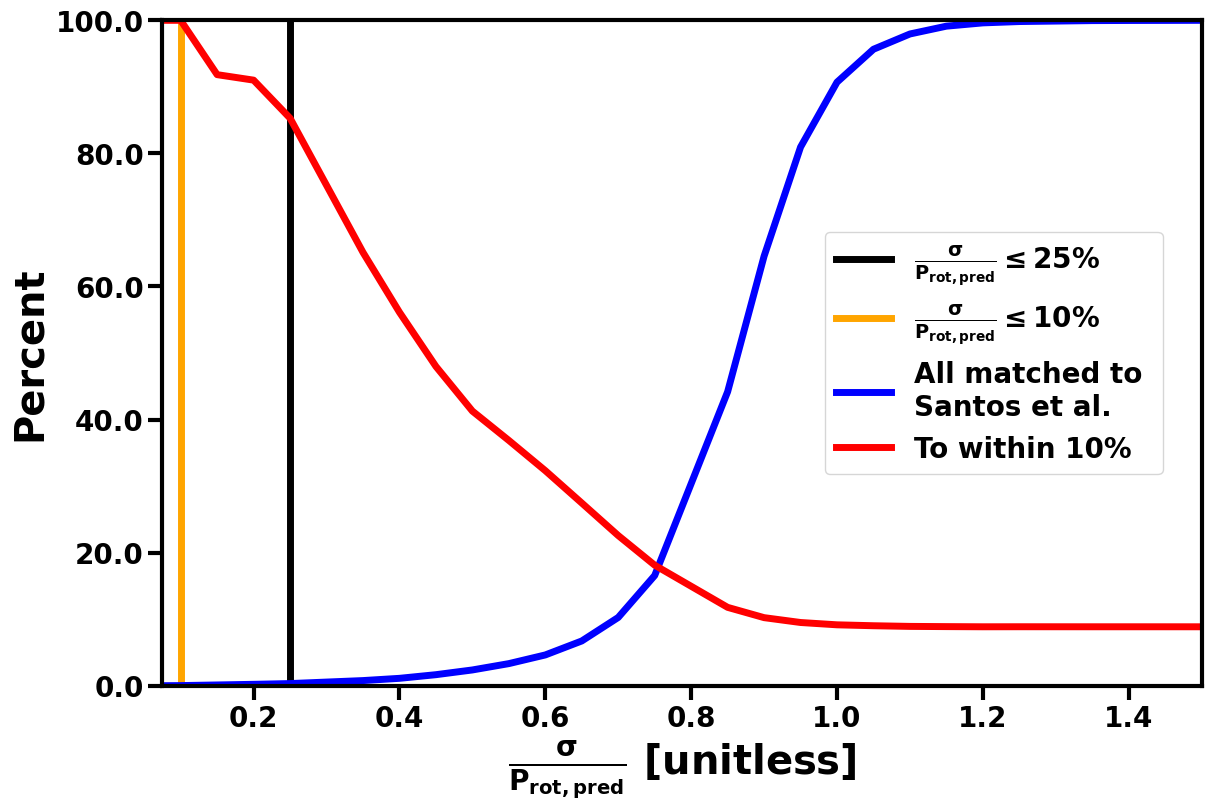

In [272]:
fig, ax = plt.subplots(figsize=(12, 8), layout='constrained')
ax.set(ylim=(0, 100), xlim=(0.075, 1.5))

formatter = ticker.FormatStrFormatter('%.4f')
ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)

ax.plot([0.25, 0.25], [0, 100], c='k', label=r'$\mathbf{\frac{\sigma}{P_{rot, pred}} \leq 25\%}$', linewidth=5)
ax.plot([0.1, 0.1], [0, 100], c='orange',label=r'$\mathbf{\frac{\sigma}{P_{rot, pred}} \leq 10\%}$', linewidth=5)
        
ax.plot(uncertainties, fracdetectedfin, c='b', label='All matched to \nSantos et al.', linewidth=5)
ax.plot(uncertainties, percenttoten, c='r', label='To within 10%', linewidth=5)

yticksl = ax.get_yticks()
ax.set_yticks(ticks = yticksl, labels=yticksl, weight='bold')
ax.set_xticks(ticks = [0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4], labels=[0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4], weight='bold')

ax.set_xlabel(r'$\mathbf{\frac{\sigma}{P_{rot, pred}}}$ [unitless]')
ax.set_ylabel('Percent')
ax.legend(prop={'weight': 'bold'}, bbox_to_anchor=(0.8, 0.5), loc='center')
plt.savefig('fracerr_uplot.pdf', dpi=300)

In [ ]:
allpred = pd.read_csv('(#path to#))0fullpred.csv', header=None, names=['asas_sn_id', 'period', 'sigma'])

In [276]:
allpred['frac'] = allpred['sigma']/allpred['period']
fracerr25 = allpred[allpred['frac']<0.25]
len(fracerr25[fracerr25['period']<5])

0

In [277]:
allpred['frac'] = allpred['sigma']/allpred['period']
sig5 = allpred[allpred['sigma']<=7]
len(sig5[sig5['period']<5])

1185

In [ ]:
del allpred